# Emerging-market bonds pay a fat spread. Do you ever get to keep it? 🌍
### EM debt carry — a coupon that's absolutely real, and a payoff that mostly isn't, in plain English

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survives_the_crises%3F: Mixed](https://img.shields.io/badge/Survives_the_crises%3F-Mixed-8b949e?style=flat-square)

Walk into any private bank and you'll hear it: *"Emerging-market government bonds yield three to four percent more than US Treasuries. That's carry — income you collect for taking a bit of exotic risk."* And the first half is completely true: the coupons really are fatter, every single year.

The question this study asks is the second half: after eighteen and a half years of defaults, taper tantrums, currency crises, a pandemic and a war — did the people who held the fund actually **keep** the spread?

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the beta regression and the crisis ledger? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We use the index funds that package the trade — EMB (dollar-denominated EM bonds, listed just before the 2008 crash) and EMLC (local-currency EM bonds) — against IEF (US Treasuries of the same ~7-year duration). Index funds keep their corpses: Venezuela's default, Lebanon's, Russia 2022 are all *in* these numbers. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from em_debt_carry import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    TR, PX = data.load_real()
    MTR, MPX = st.aligned_monthly(TR, PX, ["EMB", "IEF", "SPY", "BIL"])
else:
    TR = PX = MTR = MPX = None
print("real EM-debt cache present:", HAVE_REAL,
      "| months:", (0 if MTR is None else len(MTR)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2008-01-31', 'end': '2026-06-30', 'n_months': 222, 'years': 18.5, 'coupon_emb': 4.97, 'coupon_emb_t': 35.2, 'coupon_ief': 2.46, 'pickup_bps': 20.24, 'pickup_ann': 2.46, 'pickup_t': 20.09, 'roll_min': 1.3, 'roll_med': 2.48, 'roll_max': 3.42, 'spread_bps': 17.83, 'spread_ann': 2.16, 'spread_t': 0.99, 'skew': -1.72, 'wealth_emb': 232.8, 'wealth_ief': 170.2, 'perf': [('EMB', 4.67, 11.44, 0.35, -26.74), ('IEF', 2.92, 6.71, 0.27, -23.15), ('SPY', 11.24, 15.72, 0.68, -46.32), ('BIL', 1.27, 0.54, None, -0.42)], 'off_bps': -438.0, 'rest_bps': 70.5, 'gap_bps': -508.5, 'gap_welch': -4.84, 'corr_spy': 0.69, 'n_off': 23, 'n_rest': 199, 'cut_pct': -5.3, 'alpha_bps': -19.35, 'alpha_ann': -2.3, 'alpha_t': -1.44, 'b_ief': 0.77, 'b_ief_t': 4.71, 'b_spy': 0.46, 'b_spy_t': 7.85, 'r2': 0.57, 'emlc_n': 191, 'emlc_start': '2010-08-31', 'emlc_coupon': 5.6, 'emlc_pickup': 3.29, 'emlc_pickup_t': 21.55, 'emlc_spread_bps': -5.16, 'emlc_spread_ann': -0.62, 'emlc_spread_t': -0.24, 'emlc_wealth': 118.2, 'ief_wealth_lc': 139.8, 'emb_lc_spread_ann': 2.17, 'emb_lc_spread_t': 1.24, 'fx_bill_bps': 23.09, 'fx_bill_ann': 2.81, 'fx_bill_t': 1.81, 'ledger': [('GFC 2008', -17.33, 7), ('Taper tantrum 2013', -2.91, 5), ('EM stress 2018', -5.29, 8), ('COVID 2020', -18.79, 3), ('Rate/Russia 2022', -9.83, 10)], 'n_crisis': 33, 'n_calm': 189, 'crisis_bps': -164.1, 'calm_bps': 49.6, 'calm_t': 3.38, 'crisis_cum': -54.1, 'calm_cum': 93.7, 'total_cum': 39.6, 'ledger_welch': -2.15, 'handback': 58, 'crisis_dd': [('GFC 2008', -34.1, None, -6.0, -46.0), ('Taper 2013', -14.5, -15.5, -9.1, -5.6), ('EM 2018', -6.4, -16.6, -2.7, -9.9), ('COVID 2020', -26.5, -20.6, -4.7, -33.7), ('2022', -26.0, -20.1, -17.4, -24.5)], 'robust': [('NW lags=3', 17.83, 0.96), ('NW lags=6', 17.83, 0.99), ('NW lags=12', 17.83, 1.1), ('ex-GFC 2010+', 16.46, 1.17), ('2016-07+', 23.46, 1.23)], 'syn': [(0.0, 0.0, 4.54, 0.61, 26.1, 1.21), (30.0, 0.45, 62.91, 3.85, -376.4, -14.41)], 'fingerprint': '1bff8a946cdf'}


real EM-debt cache present: True | months: 222


## The answer first

| Question | Answer |
|---|---|
| Is the fat coupon real? | **Completely.** EM bonds paid about **+2.5%/yr more coupon** than Treasuries, in *every* rolling year of the sample. The promise is never absent. |
| Do you get to keep it? | **Not reliably.** The *collected* spread over Treasuries was +2.2%/yr on average — but so violent in crashes that 18.5 years of data **can't statistically tell it from zero**. |
| When does it hurt? | **Exactly when your stocks hurt.** In the worst 10% of stock-market months, the EM "bond" spread lost **−4.4% per month**. It's equity risk in a bond wrapper. |
| What about local-currency EM bonds? | **Worse.** EMLC paid an even fatter coupon (+5.6%/yr) and still **lost to Treasuries** over 16 years — the currencies ate all of it. |

> The coupon is real. The *keeping* is the problem — and that's the difference between a yield and a return.

## 1 · The claim

> *"EM sovereigns yield 300-450 bp over Treasuries. That spread is carry — hold the bonds, collect the difference, and the occasional default is more than covered."*

It's one of the oldest pitches in fixed income, and it has serious academic backing on *both* sides: one camp (Klingen-Weder-Zettelmeyer, IMF) found a century of EM lending earned roughly Treasury returns once defaults were counted; another (Meyer-Reinhart-Trebesch, *Sovereign Bonds since Waterloo*) found a real 3-4%/yr premium — punctuated by catastrophes. We drop the debate onto the modern, actually-investable tape: the ETFs.

## 2 · So what?

Millions of retirement portfolios hold EM debt funds precisely for "the extra yield." If the spread is genuinely collected, it's a legitimate diversifier that pays. If it's insurance-selling — steady coupons that get handed back in every crisis, at the same moment equities fall — then the allocation is just **more of the risk you already had**, wearing a bond costume. Which one it is changes what the fund is *for*.

## 3 · How would we even know?

Simple, honest bookkeeping on **18.5 years** of the packaged trade (2008-01-31 → 2026-06-30, 222 months, 2008 crash included):

1. **Split the promise from the payoff.** Every fund's return = price move + distributions. Running the tape twice (total-return and price-only) isolates the **coupon stream** — the promised carry — from what the price gave back.
2. **Match the duration.** EMB's bonds have ~7 years of rate risk; so does IEF. Comparing them head-to-head cancels the interest-rate bet and leaves the **EM premium** itself.
3. **Condition on the storm.** Look at the spread in the months the stock market fell hardest, and inside five named crises (2008, 2013, 2018, 2020, 2022): is the carry still there when everything else is on fire?

## 4 · The teardown — let's actually look

**First, the promise vs the payoff.** The coupon pickup EM bonds *promised* over Treasuries, next to the total-return spread holders actually *collected*.

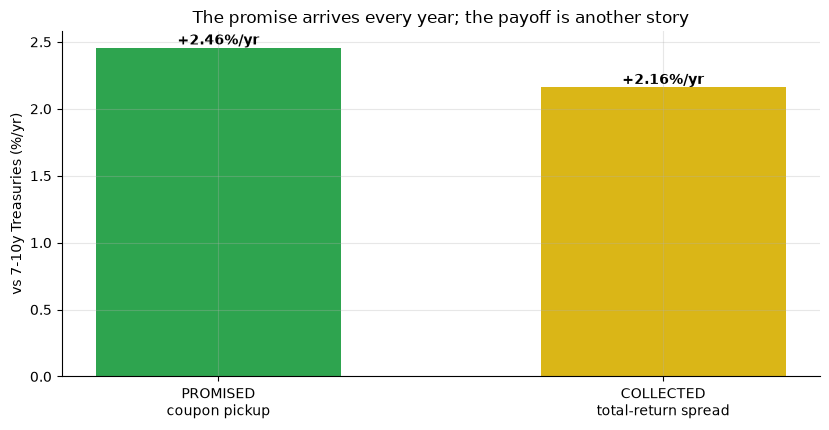

promised +2.46%/yr  vs  collected +2.16%/yr


In [2]:
if HAVE_REAL:
    yp = st.yield_pickup(MTR, MPX, 'EMB', 'IEF')
    ss = st.spread_stats(MTR, 'EMB', 'IEF')
    promised, collected = yp['pickup_ann_pct'], ss['spread_ann_pct']
else:
    promised, collected = R['pickup_ann'], R['spread_ann']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['PROMISED\ncoupon pickup','COLLECTED\ntotal-return spread'], [promised, collected],
       color=[GREEN, AMBER], width=.55)
for i, v in enumerate([promised, collected]):
    ax.annotate(f'{v:+.2f}%/yr', (i, v), ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('vs 7-10y Treasuries (%/yr)')
ax.set_title('The promise arrives every year; the payoff is another story')
plt.tight_layout(); plt.show()
print(f'promised {promised:+.2f}%/yr  vs  collected {collected:+.2f}%/yr')

Looks close — **+2.46%/yr promised, +2.16%/yr collected** — until you ask how *sure* we are of each number. The coupon pickup is so steady it's certain beyond doubt (it was positive in **every** rolling year, between +1.3% and +3.4%). The collected spread is so lumpy that 18.5 years of data **cannot statistically distinguish it from zero** — the quants notebook puts the certainty score at about **1** where the bar for "real" is **2** (the coupon scores **20**).

**Where does the difference go? Watch the wealth race.** $100 in each fund, total-return, with the five crisis windows shaded.

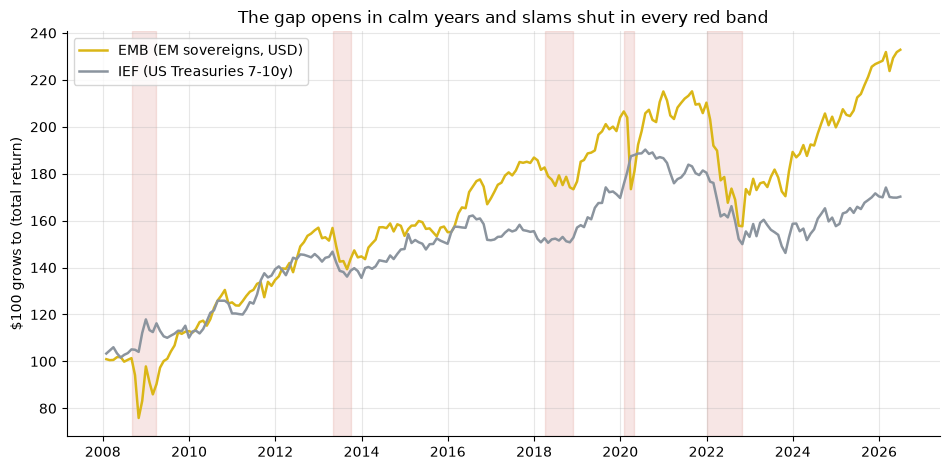

final: EMB $232.8  vs  IEF $170.2


In [3]:
if HAVE_REAL:
    w_emb = (1 + MTR['EMB']).cumprod() * 100
    w_ief = (1 + MTR['IEF']).cumprod() * 100
    fig, ax = plt.subplots(figsize=(9.6, 4.8))
    ax.plot(w_emb.index, w_emb, color=AMBER, lw=1.8, label='EMB (EM sovereigns, USD)')
    ax.plot(w_ief.index, w_ief, color=GREY, lw=1.8, label='IEF (US Treasuries 7-10y)')
    for lab, a, b in st.CRISES:
        ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=RED, alpha=.12)
    ax.set_ylabel('$100 grows to (total return)')
    ax.set_title('The gap opens in calm years and slams shut in every red band')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'final: EMB ${w_emb.iloc[-1]:.1f}  vs  IEF ${w_ief.iloc[-1]:.1f}')
else:
    print(f"final: EMB ${R['wealth_emb']:.1f}  vs  IEF ${R['wealth_ief']:.1f} (frozen; cache missing)")

EMB does finish ahead — **$233 vs $170** — but look at *how*: a staircase up in calm markets, an elevator down in every shaded crisis. That shape (statisticians call it **skew −1.7**) is why the average can be positive while the evidence stays inconclusive: a handful of catastrophic months carries most of the information.

**And the crashes are not random — they're your stock crashes.** Average monthly spread in the worst 10% of stock-market months vs all the others.

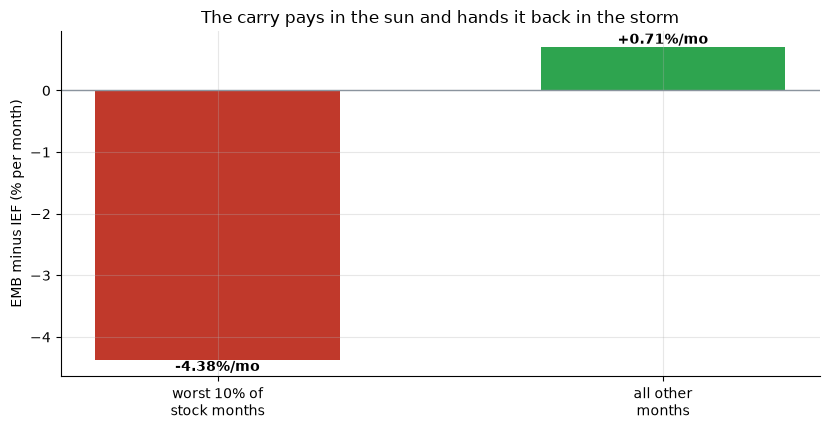

worst-decile stock months: -4.38%/mo   other months: +0.71%/mo


In [4]:
if HAVE_REAL:
    ro = st.riskoff_profile(MTR, 'EMB', 'IEF')
    off, rest = ro['off_bps_mo'] / 100, ro['rest_bps_mo'] / 100
else:
    off, rest = R['off_bps'] / 100, R['rest_bps'] / 100
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['worst 10% of\nstock months', 'all other\nmonths'], [off, rest], color=[RED, GREEN], width=.55)
for i, v in enumerate([off, rest]):
    ax.annotate(f'{v:+.2f}%/mo', (i, v), ha='center',
                va='top' if v < 0 else 'bottom', fontweight='bold')
ax.axhline(0, color=GREY, lw=1)
ax.set_ylabel('EMB minus IEF (% per month)')
ax.set_title('The carry pays in the sun and hands it back in the storm')
plt.tight_layout(); plt.show()
print(f'worst-decile stock months: {off:+.2f}%/mo   other months: {rest:+.2f}%/mo')

**-4.4% per month** when stocks are in their worst decile, **+0.7%** the rest of the time. The correlation between the EM spread and the stock market is **+0.69** — this "bond diversifier" is, to a first approximation, **equity risk with a coupon stapled on**. In fact, once you account for its Treasury exposure *and* its hidden stock-market exposure, EMB delivered slightly **less** than the copycat mix (-2.3%/yr, not statistically distinguishable from zero) — a do-it-yourself blend of a Treasury fund and an S&P fund replicated the whole package with nothing left over.

**One more twist — the local-currency version.** EMLC holds the same governments' bonds in *their own* currencies, with an even fatter coupon (**+5.6%/yr**). Over 16 years it turned $100 into **$118** while boring old Treasuries made **$140**. The currencies depreciated away the entire pickup and then some — the *only* version of this carry that ever worked is the one denominated in dollars.

## 5 · The verdict

- **Signal — Mixed.** The coupon pickup is real beyond any doubt (**+2.5%/yr**, certainty score ~20). The *collected* spread — the actual claim — averaged +2.2%/yr but is statistically indistinguishable from zero after 18.5 years (score ~1, bar = 2).
- **Tradability — Mirage.** What you collect is mostly hidden stock-market risk plus a crisis left tail; a DIY Treasuries+stocks mix matched it with nothing left over, and the local-currency version lost outright.
- **Survives the crises? — Mixed.** Arithmetically yes (+40% cumulative spread remains); statistically no — the five crises clawed back **58%** of everything the calm months collected.

## 6 · Going further 🚪

- **A yield is not a return.** The single transferable lesson: any pitch quoting a *spread* is quoting the promise, not the payoff. Ask what the *total-return* difference was, and how it behaved in the worst months.
- **The family resemblance.** Fallen-angel bonds ([610](../../610-fallen-angels-premium/README.md)) and mortgage REITs ([611](../../611-mreit-carry/README.md)) tell versions of the same packaged-carry story; the currency leg that killed EMLC is a whole study of its own ([364](../../364-fx-carry-trade/README.md)).
- **Build your own.** Swap IEF for a different duration match, move the crisis windows, or re-run since 2010 only — the code is beside every chart, and the conclusion doesn't move.

*Think the spread is collectable if you just time the exits? The quants notebook shows the whole premium lives in exactly the months nobody exits in time.*